In [4]:
!pip install yfinance pandas matplotlib


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


In [6]:
# Download Apple stock data (AAPL)
data = yf.download("AAPL", start="2023-01-01", end="2024-01-01")

# Show first few rows
data.head()


[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,


In [4]:
# Create a new column for signals: Buy (1) if today's price is higher than yesterday's, else Sell (0)
data["Signal"] = (data["Close"] > data["Close"].shift(1)).astype(int)

# Show last few rows
data.tail()


Price,Close,High,Low,Open,Volume,Signal
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2023-12-22,192.656174,194.457347,192.029240,194.228458,37122800,0
2023-12-26,192.108856,192.944757,191.889928,192.666124,28919300,0
2023-12-27,192.208374,192.556674,190.158419,191.551603,48087700,1
2023-12-28,192.636292,193.711028,192.228287,193.193559,34049900,1
2023-12-29,191.591370,193.452248,190.795267,192.954686,42628800,0


In [5]:
# Daily returns (percent change)
data["Daily Return"] = data["Close"].pct_change()

# Strategy returns (only when Signal = 1)
data["Strategy Return"] = data["Signal"].shift(1) * data["Daily Return"]

# Calculate total profit/loss
total_profit = data["Strategy Return"].sum() * 100  # Assume $100 initial investment
print(f"Total Profit/Loss: {total_profit:.2f}%")


Total Profit/Loss: 27.26%


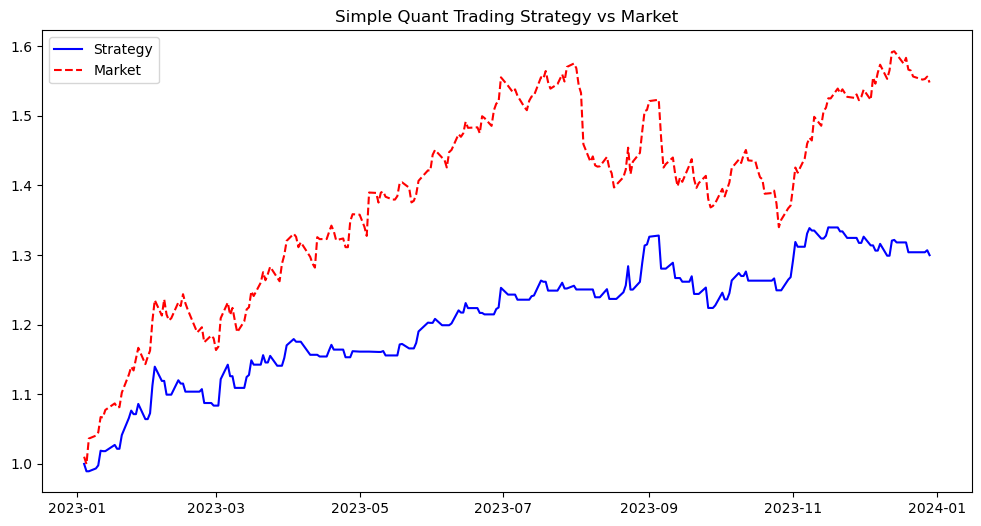

In [6]:
plt.figure(figsize=(12, 6))
plt.plot((1 + data["Strategy Return"]).cumprod(), label="Strategy", color="blue")
plt.plot((1 + data["Daily Return"]).cumprod(), label="Market", color="red", linestyle="dashed")
plt.legend()
plt.title("Simple Quant Trading Strategy vs Market")
plt.show()
